## Random Forest Algorithm For Multiclass Classification

## Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## Data Loading & Exploration

In [2]:
df = pd.read_csv(r'data\Social_media_impact_on_life.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   object 
 3   Academic_Level                1705 non-null   object 
 4   Country                       1705 non-null   object 
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   object 
 7   Affects_Academic_Performance  1705 non-null   object 
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 146.7+ KB


In [4]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative


In [5]:
df.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000
mean,439.510264,20.848094,5.103636,6.598710,6.215132
std,267.058174,1.758557,1.677341,1.207045,1.282678
min,1.000000,18.000000,1.500000,3.800000,4.000000
25%,214.000000,19.000000,3.800000,5.600000,5.000000
50%,427.000000,21.000000,5.100000,6.600000,6.000000
75%,640.000000,22.000000,6.300000,7.500000,7.000000
max,1000.000000,24.000000,8.500000,9.600000,9.000000


In [6]:
df.isna().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
dtype: int64

In [7]:
df.shape

(1705, 11)

In [8]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Overall_Impact'],
      dtype='object')

In [9]:
df.duplicated().sum()

0

## Data Preprocessing

In [10]:
df['Gender'] = df['Gender'].map({
    'Male' : 0,
    'Female' : 1
})

In [11]:
df['Affects_Academic_Performance'] = df['Affects_Academic_Performance'].map({
    'No' : 0,
    'Yes' : 1
})

In [12]:
df['Academic_Level'] = df['Academic_Level'].map({
        'High School': 0 ,
        'Undergraduate': 1,
        'Graduate':2
})

In [13]:
df['Overall_Impact']=df['Overall_Impact'].map({
    'Negative' :0,
    'Neutral' :1,
    'Positive' :2
})

In [14]:
df=pd.get_dummies(
    df,
    columns=['Most_Used_Platform','Country'],
    drop_first= True,
    dtype= int
)

In [15]:
X=df.drop(['Overall_Impact','Student_ID','Mental_Health_Score'], axis=1)
y=df['Overall_Impact']

In [16]:
X

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Affects_Academic_Performance,Sleep_Hours_Per_Night,Most_Used_Platform_Instagram,Most_Used_Platform_KakaoTalk,Most_Used_Platform_LINE,Most_Used_Platform_LinkedIn,...,Country_UAE,Country_UK,Country_USA,Country_Ukraine,Country_Uruguay,Country_Uzbekistan,Country_Vatican City,Country_Venezuela,Country_Vietnam,Country_Yemen
0,21,0,1,4.0,0,6.7,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,23,1,1,1.6,0,8.6,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,22,0,2,4.6,0,6.7,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,18,0,1,7.0,1,5.4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,24,1,0,7.5,1,5.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1700,20,1,1,4.7,0,7.2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1701,23,0,2,6.8,1,5.9,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1702,21,1,1,5.6,1,6.7,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1703,24,0,2,4.3,0,7.5,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
y

0       1
1       2
2       1
3       0
4       0
       ..
1700    2
1701    0
1702    0
1703    2
1704    0
Name: Overall_Impact, Length: 1705, dtype: int64

## Data Visualization

<Axes: xlabel='Gender', ylabel='count'>

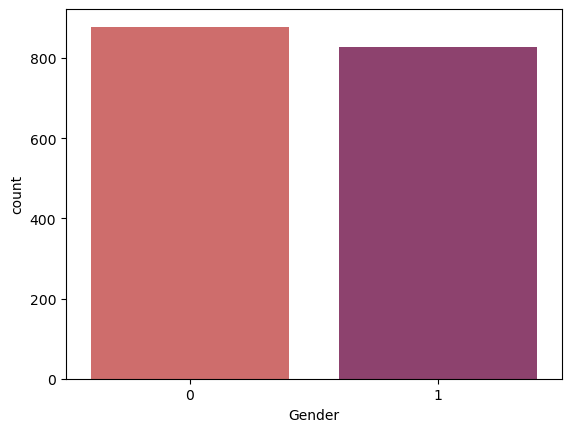

In [18]:
sns.countplot(
    x='Gender',
    data=df,
    palette='flare'
)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Count'>

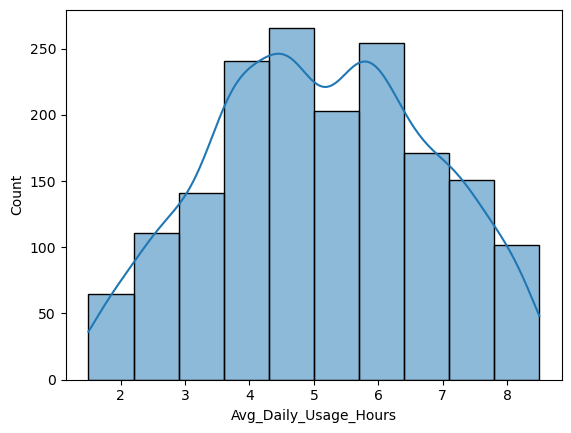

In [19]:
sns.histplot(
    df['Avg_Daily_Usage_Hours'],
    bins= 10,
    kde=True,
)

<Axes: xlabel='Overall_Impact', ylabel='count'>

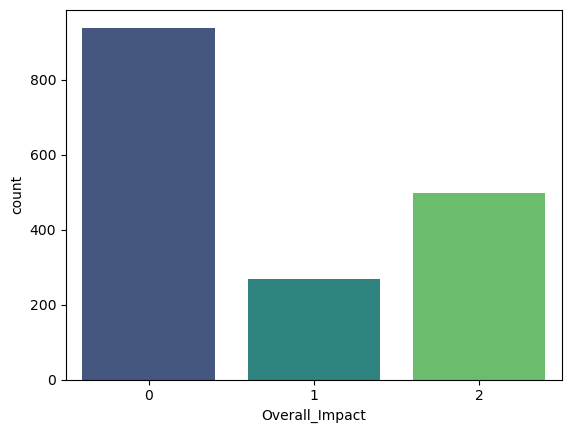

In [20]:
sns.countplot(
    x='Overall_Impact',
    data=df,
    palette='viridis'
)

## Train/Test Split & Model Training

In [21]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=True,random_state=42,stratify=y)

In [62]:
model=RandomForestClassifier(
    random_state=42,
    max_depth=4,
    n_estimators=100,
    class_weight='balanced'
    )

In [63]:
model.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=4, random_state=42)

In [64]:
train_accuracy=model.score(X_train,y_train)
test_accuracy=model.score(X_test,y_test)

In [65]:
train_accuracy

0.9406158357771262

In [66]:
test_accuracy

0.9032258064516129

## Model Predection

In [67]:
y_pred = model.predict(X_test)
y_pred

array([0, 2, 2, 0, 2, 0, 0, 0, 0, 0, 2, 2, 0, 1, 0, 0, 0, 0, 0, 2, 1, 1,
       2, 2, 0, 0, 2, 2, 2, 0, 2, 1, 0, 2, 2, 0, 2, 0, 2, 2, 0, 1, 2, 0,
       1, 0, 0, 0, 0, 1, 2, 0, 2, 2, 1, 2, 2, 2, 2, 0, 0, 0, 2, 0, 2, 1,
       2, 0, 0, 0, 0, 0, 2, 0, 0, 1, 2, 0, 0, 0, 0, 1, 2, 0, 0, 2, 0, 2,
       1, 2, 0, 1, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 0, 2,
       1, 0, 0, 0, 0, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 2, 2, 0, 0, 2, 1, 1, 0, 0, 2, 0, 2, 2, 1, 2, 0, 2, 2, 1,
       1, 0, 2, 0, 0, 1, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 0, 0, 2, 2, 0, 0,
       2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 0, 0, 2, 0, 0, 1, 2, 0, 2,
       0, 1, 0, 0, 0, 2, 0, 2, 2, 0, 0, 0, 2, 0, 1, 0, 2, 2, 0, 0, 1, 2,
       0, 2, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 2, 2, 0, 2, 1, 1, 2, 0, 2, 1,
       2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 2, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 1, 2, 2, 0, 0, 2, 0, 0, 2, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2,
       0, 2, 2, 0, 2, 0, 2, 1, 2, 2, 0, 0, 2, 2, 0,

In [68]:
pred_probabilities = model.predict_proba(X_test)
pred_probabilities

array([[0.64535937, 0.22908227, 0.12555836],
       [0.17521939, 0.32028649, 0.50449412],
       [0.18880408, 0.28814634, 0.52304958],
       ...,
       [0.17521939, 0.32028649, 0.50449412],
       [0.14712323, 0.20768465, 0.64519211],
       [0.47421167, 0.25591689, 0.26987144]])

## Evaluation

In [69]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred,average='weighted')
recall=recall_score(y_test,y_pred,average='weighted')
f1score=f1_score(y_test,y_pred,average='weighted')
classificationreport = classification_report(y_test,y_pred)

In [70]:
accuracy

0.9032258064516129

In [71]:
precision

0.9116160269719321

In [72]:
recall

0.9032258064516129

In [73]:
f1score

0.9024521204555321

In [74]:
classificationreport

'              precision    recall  f1-score   support\n\n           0       0.98      0.94      0.96       188\n           1       0.90      0.68      0.77        53\n           2       0.79      0.96      0.87       100\n\n    accuracy                           0.90       341\n   macro avg       0.89      0.86      0.87       341\nweighted avg       0.91      0.90      0.90       341\n'

In [75]:
results=pd.DataFrame({
    'Actual OverAll Imapact ' : y_test.values,
    'Predicted OverAll Imapact ' : y_pred
})
results

,Actual OverAll Imapact,Predicted OverAll Imapact
0,0,0
1,2,2
2,2,2
3,0,0
4,0,2
...,...,...
336,1,1
337,1,1
338,2,2
339,2,2


## Confusion Matrix

Text(0.5, 1.0, 'Confusion Matrix')

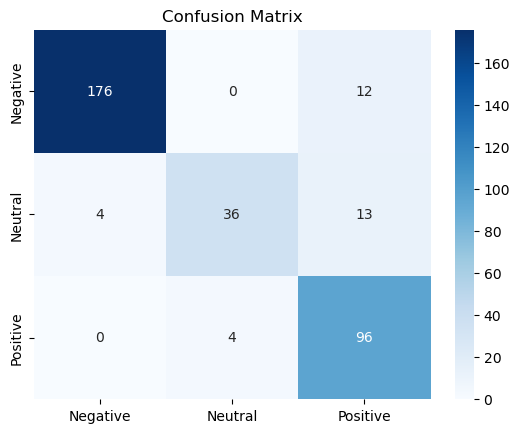

In [76]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative','Neutral','Positive'],
    yticklabels=['Negative','Neutral','Positive']
)
plt.title('Confusion Matrix')

## Feature Importances

In [77]:
importance = pd.Series(model.feature_importances_,index=X.columns)
importance = importance.sort_values(ascending=False).head(10)

importance

Sleep_Hours_Per_Night           0.291621
Avg_Daily_Usage_Hours           0.189672
Affects_Academic_Performance    0.134664
Country_Other                   0.044139
Country_Denmark                 0.036254
Most_Used_Platform_WhatsApp     0.028817
Country_France                  0.024350
Country_Switzerland             0.023568
Age                             0.023457
Most_Used_Platform_TikTok       0.022835
dtype: float64

Text(0, 0.5, 'Feature')

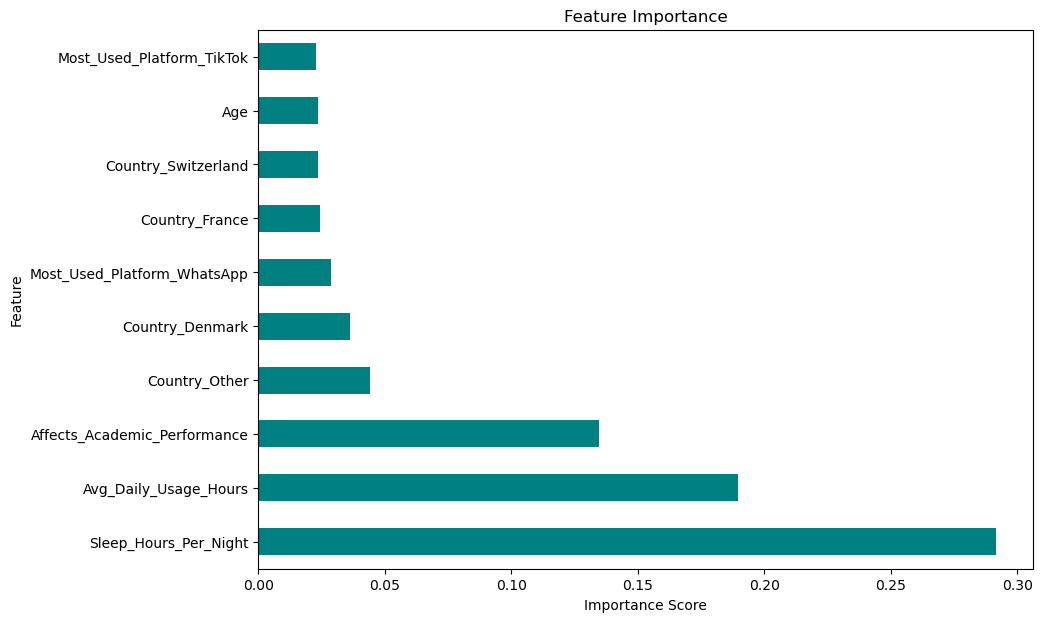

In [78]:
plt.figure(figsize=(10,7))
importance.plot(kind='barh', color='teal')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')